In [1]:
import os
import sys
sys.path.append("../..")

import dill as pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.distributions as td
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as pyg
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.datasets import TUDataset

from egg_models import egg_generic_losses
from egg_models.egg_generic import EggGeneric
from egg_models.egg_generic import EggGeneric
from functools import partial
from matplotlib.patches import ConnectionPatch
from scipy.stats import gaussian_kde, t
from sklearn.metrics import confusion_matrix

from utils import mutag_helper
from utils import visuals
import pygmtools as pygm
import networkx as nx

from egg_models.egg_generic_losses import activation_hook, dict_cos_dist, GEDasMatchLoss
from scipy.stats import stats

2024-10-10 10:30:47.415525: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-10 10:31:05.570586: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

#Meta-Data
device = torch.device(0)
node_types = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']
color_palette = np.array(['orange', 'magenta', 'green', 'blue', 'cyan', 'red', 'lime'])
color_palette_dropped = np.array(['orange', 'magenta', 'green', 'blue', 'red'])

# Data Prep

## Helper Functions

In [3]:
# Explainee Model
class GCN(torch.nn.Module):
    def __init__(self, node_features, hc1=64, hc2=32, hc3=16):
        super().__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(node_features, hc1)
        self.conv2 = GCNConv(hc1, hc2)
        self.conv3 = GCNConv(hc2, hc3)
        self.lin = nn.Linear(hc3, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

In [4]:
def train_explainee(
    explainee: nn.Module,
    train_data: list, 
    test_data: list, 
    ):

    train_data_loader = pyg.loader.DataLoader(train_data, 
                                            batch_size=16, shuffle=True)
    test_data_loader = pyg.loader.DataLoader(test_data, 
                                            batch_size=16, shuffle=False)

    optimizer = torch.optim.Adam(explainee.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(201): 
        explainee.train()        
        for batch in train_data_loader: 
            out = explainee(batch)
            loss = criterion(out, batch.y)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

        explainee.eval()
        correct = 0
        for batch in train_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        train_accuracy = correct / len(train_data_loader.dataset)

        correct = 0
        for batch in test_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        test_accuracy = correct / len(test_data_loader.dataset)

        print(f"Epoch: {epoch} Train Accuracy: {train_accuracy} " + 
            f"Test Accuracy: {test_accuracy}")


    full_batch = pyg.data.Batch.from_data_list(test_data)
    explainee.eval()
    preds = explainee(full_batch).argmax(dim=1).numpy()
    targets = full_batch.y.numpy()

    conf_matrix = confusion_matrix(targets, preds)
    print(conf_matrix)

    return explainee

In [5]:
def extract_embeddings(
    explainee: nn.Module, 
    train_data: list, 
    ):

    activation_names = ["conv1", "conv2", "conv3"]
    train_avg_embedding_0 = {"conv1": [], "conv2": [], "conv3": []}
    train_avg_embedding_1 = {"conv1": [], "conv2": [], "conv3": []}
    pool_func = pyg.nn.global_mean_pool


    train_data_loader = pyg.loader.DataLoader(train_data)
    for batch in train_data_loader:
        explainee.eval()

        acts, remove_hooks = activation_hook(explainee, activation_names)
        out = explainee(batch)
        remove_hooks()

        if batch.y.item() == 0: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_0[name].append(
                    embed.detach().to('cpu')
                )

        if batch.y.item() == 1: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_1[name].append(
                    embed.detach().to('cpu')
                )
                
    for name in activation_names:
        train_avg_embedding_0[name] = torch.stack(
            train_avg_embedding_0[name]
        ).mean(dim=0)

        train_avg_embedding_1[name] = torch.stack(
            train_avg_embedding_1[name]
        ).mean(dim=0)

    return train_avg_embedding_0, train_avg_embedding_1

## Raw Data

In [6]:
# Raw data

# Download data. 
data_raw = TUDataset(root='data/TUDataset', name='MUTAG')

# Shuffle
data_raw = data_raw.shuffle()

# Split 
train_data = data_raw[:150]
test_data = data_raw[150:]

# Create data lists
train_data_list = []
train_data_list_0 = []
train_data_list_1 = []
test_data_list = []
test_data_list_0 = []
test_data_list_1 = []

for graph in train_data:
    train_data_list.append(graph)

    if graph.y.item() == 0: 
        train_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_1.append(graph)

for graph in test_data:
    test_data_list.append(graph)

    if graph.y.item() == 0: 
        test_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_1.append(graph)

In [7]:
explainee_raw = train_explainee(
    GCN(node_features=7), 
    train_data_list, test_data_list
)

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [8]:
train_avg_embedding_0, train_avg_embedding_1 = extract_embeddings(
    explainee_raw, train_data_list
)
print(train_avg_embedding_0)
print(train_avg_embedding_1)

{'conv1': tensor([[-2.5616e-02,  3.5865e-02,  2.2708e-02, -6.0919e-02,  1.1478e-01,
         -5.7976e-02,  1.5329e-01, -5.8544e-02,  3.1236e-01,  7.9226e-03,
         -1.5723e-01,  7.3637e-02,  5.1356e-03, -8.6245e-02, -1.9665e-01,
         -4.6060e-03, -2.4553e-02,  2.6134e-03,  8.7952e-05, -1.6012e-01,
         -3.5422e-02,  1.2097e-01,  7.3860e-02, -1.3997e-01,  1.7250e-02,
          2.4613e-02, -6.1222e-02,  1.6407e-01, -3.2518e-01,  1.7116e-01,
         -3.1727e-02, -1.1589e-01,  4.7401e-03, -1.2909e-01,  7.1675e-02,
         -4.0509e-02, -7.7566e-02,  5.2777e-02, -4.0029e-03,  1.4338e-01,
         -6.6134e-02,  1.6166e-02,  4.7563e-02, -3.2336e-02, -4.8085e-02,
         -1.2039e-01, -1.2067e-01,  5.8204e-02, -6.6188e-03,  2.4483e-03,
          1.2473e-02,  7.1323e-02, -2.3756e-02, -1.6651e-01,  1.5828e-02,
          4.1388e-02, -8.7087e-02,  7.0760e-04, -6.4389e-02, -2.5253e-04,
         -3.3731e-02,  6.5148e-03,  1.2479e-01, -9.7723e-02]]), 'conv2': tensor([[-0.0645, -0.0451,  0

## Dropped

In [9]:
data_dropped = []

for graph in data_raw:
    node_types = graph.x.argmax(dim=-1)
    edge_types = graph.edge_attr.argmax(dim=-1)

    if torch.any(node_types == 4) or torch.any(node_types == 6) or torch.any(edge_types == 3): 
        print(graph) 
    else: 
        graph.x = torch.cat([graph.x[:, :4], graph.x[:, 5].unsqueeze(1)], dim=1)
        graph.edge_attr = graph.edge_attr[:, :3]
        data_dropped.append(graph)

data_dropped[1]

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 28], x=[14, 7], edge_attr=[28, 4], y=[1])
Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 40], x=[18, 7], edge_attr=[40, 4], y=[1])


Data(edge_index=[2, 38], x=[17, 5], edge_attr=[38, 3], y=[1])

In [10]:
# Split 
train_data_dropped = data_dropped[:150]
test_data_dropped = data_dropped[150:]

# Create data lists
train_data_list_dropped = []
train_data_list_dropped_0 = []
train_data_list_dropped_1 = []
test_data_list_dropped = []
test_data_list_dropped_0 = []
test_data_list_dropped_1 = []

for graph in train_data_dropped:
    train_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        train_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_dropped_1.append(graph)

for graph in test_data_dropped:
    test_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        test_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_dropped_1.append(graph)

In [11]:
explainee_dropped = train_explainee(
    GCN(node_features=5), 
    train_data_list_dropped, 
    test_data_list_dropped
)  

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [12]:
train_avg_embedding_0_dropped, train_avg_embedding_1_dropped = extract_embeddings(
    explainee_dropped, train_data_list_dropped
)
print(train_avg_embedding_0_dropped)
print(train_avg_embedding_1_dropped)

{'conv1': tensor([[-0.0276,  0.0798,  0.1924,  0.1729, -0.0075,  0.1216,  0.0237,  0.1757,
          0.1126, -0.0739, -0.0710, -0.0031, -0.0275, -0.0070,  0.0217, -0.0237,
          0.0092,  0.0541, -0.0590,  0.0186, -0.1923, -0.0211,  0.1099,  0.0057,
         -0.0199, -0.0091,  0.1507,  0.0507, -0.0247,  0.0169,  0.0005,  0.1497,
          0.0133,  0.0581,  0.1614, -0.0114, -0.0009, -0.0009, -0.0342,  0.0246,
         -0.0813, -0.0117,  0.0851, -0.1581, -0.0043, -0.2818,  0.1122,  0.0074,
          0.1568,  0.0783, -0.0099,  0.0165,  0.0343,  0.1089, -0.0192,  0.1614,
         -0.0093,  0.1375,  0.0141,  0.0689,  0.1716, -0.0262,  0.0517,  0.0913]]), 'conv2': tensor([[-0.1885,  0.1674,  0.1749, -0.1000,  0.0770,  0.1459,  0.2849,  0.1932,
         -0.0510,  0.0812, -0.1993, -0.2232,  0.1412, -0.2686, -0.2893, -0.2965,
         -0.2149, -0.1909, -0.0599, -0.2064, -0.1401,  0.1115,  0.1477, -0.0557,
          0.1658,  0.2561,  0.1316, -0.1155, -0.1595, -0.1507,  0.1499,  0.1483]]), 'co

# EGG

## Helper Functions

In [73]:
def t_confidence_interval(data):
    mean = np.mean(data)
    std_dev = np.std(data)

    print(f"Mean {mean} SD: {std_dev}")

    n = len(data)
    t_value = t.ppf(0.975, df=n-1) 
    margin_of_error = t_value * (std_dev / np.sqrt(n))
    lower_bound = np.round(mean - margin_of_error, 4)
    upper_bound = np.round(mean + margin_of_error, 4)

    print(f"({lower_bound}, {upper_bound})")

In [95]:
def pre_acc_interval(
    generator: nn.Module, 
    explainee: nn.Module, 
    target
    ):
    generator.eval()
    explainee.eval()

    pred_acc = []
    for i in range(1000):
        with torch.no_grad():
            gen_ex = mutag_helper.egg_to_ex(generator())
            pred = torch.softmax(explainee(gen_ex), dim=-1).mean(dim=0)
            pred_acc.append(pred[target].item())
    
    t_confidence_interval(pred_acc)

In [15]:
def GED_interval(
    generator: nn.Module, 
    GED_fn: nn.Module, 
    data_list: list, 
    batch_size=16, 
    ):
    generator.eval()
    loader = pyg.loader.DataLoader(data_list, 
                                   batch_size=batch_size, drop_last=True)
    running_GED = []
    for batch in loader:
        batch = batch.to(device)
        with torch.no_grad():
            generated = generator()
            gen_ex = mutag_helper.egg_to_ex(generated)
            gen_egg = mutag_helper.egg_to_egg(generated)
            obs_egg = mutag_helper.ex_to_egg(batch)

            egg_sizes = torch.tensor([
                graph.x.shape[0] + graph.edge_index.shape[1] 
                for graph in gen_ex.to_data_list()
            ]).to(device)

            loss = (
                GED_fn(*gen_egg, *obs_egg) / 
                egg_sizes
            ).mean()

            running_GED.append(min(loss.item(), 1.0))

    t_confidence_interval(running_GED)

In [16]:
def train_egg(
    dis_node_feats: int, 
    dis_edge_feats: int, 
    explainee: nn.Module, 
    target: int, 
    train_data_list_1, 
    train_data_list_0, 
    train_data_list_full, 
    pred_loss_embeds, 
    other_class_embeds,  
    max_node_size=20, 
    temp=0.15, 
    epochs=25, 
    loss_fn_weights=torch.tensor([1.0, 1.0, 1.0, 1.0]), 
    use_egg_size=False, 
    use_omega=True,  
    batch_size=16
    ):
    # Define target tensors. 
    if target == 1:
        target_tensor = torch.tensor([0.0, 1.0])
    else: 
        target_tensor = torch.tensor([1.0, 0.0])

    # Setup explainee. 
    explainee.eval()
    explainee.to(device)

    # Define generator to train. 
    generator = EggGeneric(
        max_node_size=max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=temp, 
        batch_size=batch_size, 
    )
    generator.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    # Compute random baseline.
    print("Baseline Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Baseline % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Baseline % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    # Train EGG model.
    train_loader = pyg.loader.DataLoader(train_data_list_full, 
                                         batch_size=batch_size, drop_last=True)
    pred_loss_fn = egg_generic_losses.PredLossBatched(
        target_tensor, explainee, avg_embed_targets=pred_loss_embeds
    )
    embed_dist_fn = egg_generic_losses.EmbDistGeneric(
        explainee, avg_embed_targets=other_class_embeds
    )
    edge_pen_fn = egg_generic_losses.EdgePenalty(edge_budget = 10)
    generator.train()
    optimizer = torch.optim.RMSprop(generator.parameters()) 
    for epoch in range(epochs):
        report_loss = np.array([0.0, 0.0, 0.0, 0.0])
        for obs_batch in train_loader: 
            optimizer.zero_grad()
            obs_batch = obs_batch.to(device)
            gen_graph = generator()

            # Data formatting. 
            gen_ex = mutag_helper.egg_to_ex(gen_graph) 
            gen_egg = mutag_helper.egg_to_egg(gen_graph)
            obs_egg = mutag_helper.ex_to_egg(obs_batch)

            loss_1, _, _ = pred_loss_fn(gen_ex)
            loss_1 = loss_1.mean()

            loss_embed = -1 * embed_dist_fn(gen_ex).mean()

            #loss_edge = torch.sum(generator.AdjacencyMatrix.probs, dim=0).mean()
            loss_edge = edge_pen_fn(generator.AdjacencyMatrix.probs)

            loss_2 = GED_fn(*gen_egg, *obs_egg)
            if use_egg_size:
                egg_size = torch.tensor([
                    graph.x.shape[0] + graph.edge_index.shape[1] 
                    for graph in gen_ex.to_data_list()
                ]).to(loss_2.device)
            else: 
                egg_size = 1.0
            
            if use_omega:
                with torch.no_grad():
                    explainee_pred = F.softmax(explainee(obs_batch), dim=-1)
                    omega = (explainee_pred @ 
                        target_tensor.to(explainee_pred.device) - 0.5
                    )
            else:
                omega = 1
            loss_3 = (omega * loss_2 / egg_size).mean()

            report_loss += [loss_1.item(), loss_embed.item(), 
                            loss_edge.item(), loss_3.item()]
            report_loss
            loss = (
                loss_fn_weights.to(loss_1.device) @ 
                torch.stack((loss_1, loss_embed, loss_edge, loss_3)) 
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)

            optimizer.step() 

        report_loss = [x / len(train_loader) for x in report_loss]
        print(f"Epoch: {epoch} Losses:{report_loss}")

    print("Trained Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Trained % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Trained % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    return generator 

In [17]:
# Visualize Connected Graph
def vis_con_graph(
    generator: nn.Module, 
    explainee: nn.Module, 
    dis_node_feats: int, 
    dis_edge_feats: int, 
    target: int, 
    obs_ex1, 
    obs_ex2, 
    color_palette=color_palette
    ):

    generator_batch_1 = EggGeneric(
        max_node_size=generator.max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=generator.temp, 
        batch_size=1, 
    )
    generator_batch_1.load_state_dict(generator.state_dict())
    generator_batch_1.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=generator.max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    gen = generator_batch_1()
    gen_ex = mutag_helper.egg_to_ex(gen)
    gen_egg = mutag_helper.egg_to_egg(gen)
    colors0 = color_palette[torch.argmax(gen_ex.x, dim=-1).cpu().numpy()]
    gen_nx = pyg.utils.to_networkx(gen_ex)

    obs_ex1 = obs_ex1.to(device)
    obs_egg1 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex1]))
    colors1 = color_palette[torch.argmax(obs_ex1.x, dim=-1).cpu().numpy()]
    obs_nx = pyg.utils.to_networkx(obs_ex1)

    obs_ex2 = obs_ex2.to(device)
    obs_egg2 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex2]))
    colors2 = color_palette[torch.argmax(obs_ex2.x, dim=-1).cpu().numpy()]
    obs_nx2 = pyg.utils.to_networkx(obs_ex2)

    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg1)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)

    with torch.no_grad():
        aff_mat2 = GED_fn.get_aff_mat(*gen_egg, *obs_egg2)
        dis_match_mat2 = GED_fn.get_dis_match_mat(aff_mat2)

    egg_size = torch.tensor([
        graph.x.shape[0] + graph.edge_index.shape[1] 
        for graph in gen_ex.to_data_list()
    ]).to(device)

    GED_score1 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
        egg_size
    ).item()
    GED_score1 = min(GED_score1, 1.0) # cap at 100% edit.

    GED_score2 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat2, aff_mat2) / 
        egg_size
    ).item()
    GED_score2 = min(GED_score2, 1.0)


    pos_1 = nx.spring_layout(obs_nx)
    # pos_2 = nx.spring_layout(gen_nx)
    pos_2 = {}
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        pos_2[i] = pos_1[j]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    nx.draw(obs_nx, node_color = colors1, pos = pos_1, ax=axes[0])

    nx.draw(gen_nx, node_color = colors0, pos=pos_2, ax=axes[1])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_2[i], xyB=pos_1[j], 
                            coordsA="data", coordsB="data",
                            axesA=axes[0], axesB=axes[1], color="green")

        fig.add_artist(con)

    pos_3 = nx.spring_layout(obs_nx2)
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        pos_3[j] = pos_2[i]

    nx.draw(obs_nx2, node_color = colors2, pos = pos_3, ax=axes[2])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_3[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[2], axesB=axes[1], color="blue")

        fig.add_artist(con)

    explainee.eval()
    with torch.no_grad():
        pred_gen = torch.softmax(explainee(gen_ex), -1)[:, target].item()
        pred_obs1 = torch.softmax(explainee(obs_ex1), -1)[:, target].item()
        pred_obs2 = torch.softmax(explainee(obs_ex2), -1)[:, target].item()

    axes[0].set_title(f"Class Probability: {pred_obs1:0.2f} GED: {GED_score1:0.2f}")
    axes[1].set_title(f"Class Probability: {pred_gen:0.2f}")
    axes[2].set_title(f"GED: {GED_score2:0.2f} Class Probability: {pred_obs2:0.2f}")

# Results

## Re-implementationn of GNNInterpreter

In [18]:
gen_gnnInt_1 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0346, 0.0478)
Baseline % GED to 1
(0.0887, 0.0943)
Baseline % GED to 0
(0.0702, 0.0802)
Epoch: 0 Losses:[2.488895145329562, -0.4473442008549517, 11162.256525213068, 2.6415098959749397]
Epoch: 1 Losses:[1.340707172047008, -1.2012388922951438, 2753.4924760298295, 2.764549049464139]
Epoch: 2 Losses:[0.9785757931795988, -1.4791966026479548, 978.0284090909091, 2.808394957672466]
Epoch: 3 Losses:[0.9173114516518333, -1.5128271037882024, 351.09124755859375, 2.8872055248780684]
Epoch: 4 Losses:[0.7175553332675587, -1.651883981444619, 138.54650462757456, 2.9238709644837813]
Epoch: 5 Losses:[0.7866713892329823, -1.6152121478861028, 54.056364579634234, 2.993462259119207]
Epoch: 6 Losses:[0.6482594555074518, -1.709930051456798, 21.84810109571977, 2.9959917718713935]
Epoch: 7 Losses:[0.5527356863021851, -1.7755875695835461, 9.964755535125732, 2.9949648055163296]
Epoch: 8 Losses:[0.54624804854393, -1.783872983672402, 5.35443249615756, 2.9876218058846216]
Epoch: 9 Lo

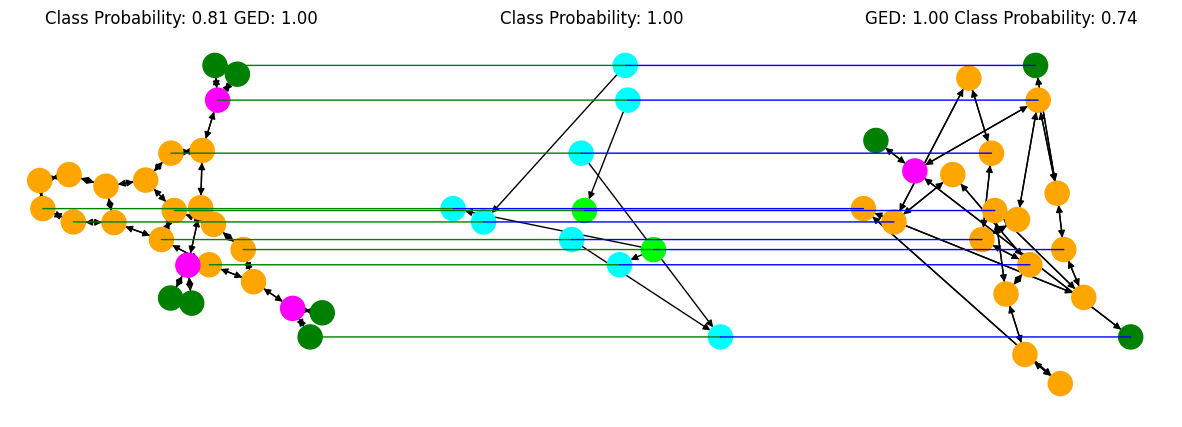

In [19]:
vis_con_graph(
    gen_gnnInt_1, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [20]:
gen_gnnInt_0 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.8713, 0.8954)
Baseline % GED to 1
(0.0821, 0.0883)
Baseline % GED to 0
(0.0639, 0.0752)
Epoch: 0 Losses:[0.4247904121875763, -1.848055904561823, 12843.299183238636, -2.7073020068081943]
Epoch: 1 Losses:[0.441915593364022, -1.840212886983698, 2039.1237127130682, -2.8160198710181494]
Epoch: 2 Losses:[0.4086053181778301, -1.859995506026528, 679.1913563121449, -2.8981673392382534]
Epoch: 3 Losses:[0.4049800119616769, -1.8659918199885974, 264.71065174449575, -2.900397441603921]
Epoch: 4 Losses:[0.3872036256573417, -1.8730974847620183, 111.45128562233664, -2.9332360245964746]
Epoch: 5 Losses:[0.38823709975589404, -1.878071828321977, 49.62339123812589, -2.904692693190141]
Epoch: 6 Losses:[0.40316673571413214, -1.8670367110859265, 23.395724036476828, -2.963702516122298]
Epoch: 7 Losses:[0.4116132990880446, -1.8580020557750354, 11.78669296611439, -2.9675759944048794]
Epoch: 8 Losses:[0.4143443324349143, -1.8579390157352795, 6.581091620705345, -2.948208093643188

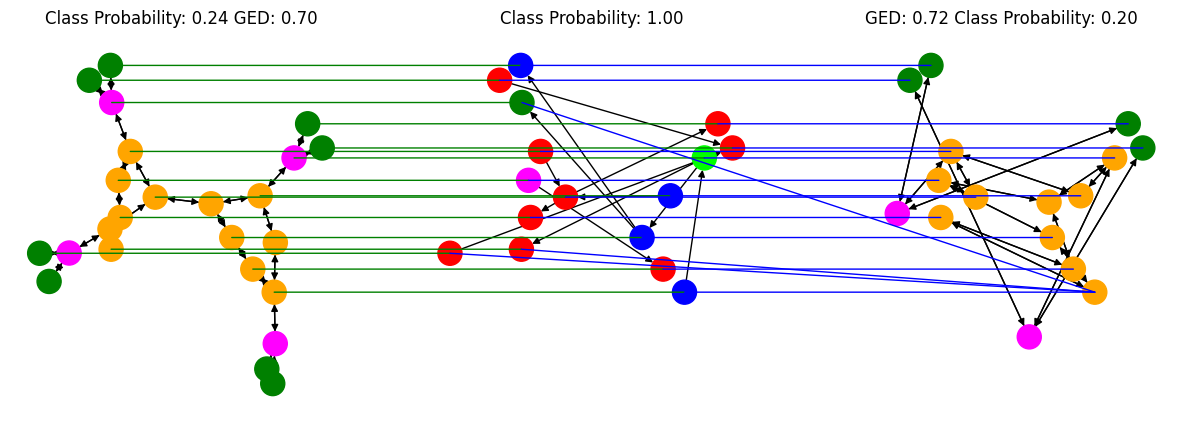

In [21]:
vis_con_graph(
    gen_gnnInt_0,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[2].clone(), 
    obs_ex2=test_data_list_0[3].clone(), 
    target=0
)

In [22]:
gen_gnnInt_1_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0129, 0.0181)
Baseline % GED to 1
(0.0796, 0.0849)
Baseline % GED to 0
(0.0613, 0.0704)
Epoch: 0 Losses:[3.0175610455599697, -0.08780327744104645, 12797.25106534091, 2.7409341497854753]
Epoch: 1 Losses:[2.936628883535212, -0.09708811376582492, 2190.296875, 2.855710333043879]
Epoch: 2 Losses:[3.0713795965368096, -0.06439570303667676, 648.1366327459162, 2.90937602519989]
Epoch: 3 Losses:[3.0695522048256616, -0.06621409546245229, 236.41784529252485, 2.9818848371505737]
Epoch: 4 Losses:[3.1081559007818047, -0.050466213036667214, 97.46385817094283, 2.960738019509749]
Epoch: 5 Losses:[3.1188912825150923, -0.05014449662782929, 42.45570859042081, 2.970829790288752]
Epoch: 6 Losses:[3.1162737066095527, -0.04966881193897941, 19.530057907104492, 3.050855961712924]
Epoch: 7 Losses:[3.099208723415028, -0.055467705157670105, 9.976993387395686, 2.8957478458231147]
Epoch: 8 Losses:[3.11594312841242, -0.050956130366433754, 5.824604728005149, 2.9946453246203335]
Epoch: 

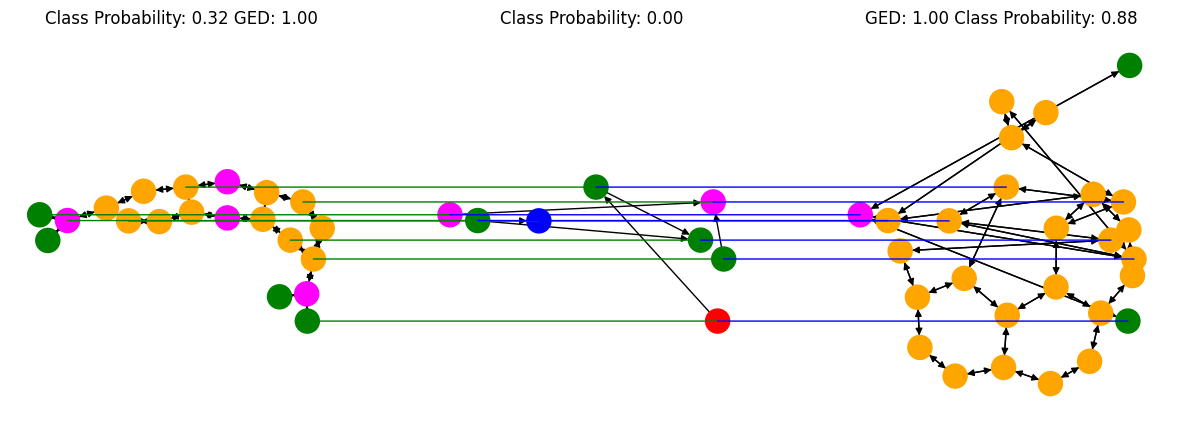

In [23]:
vis_con_graph(
    gen_gnnInt_1_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[1].clone(), 
    obs_ex2=test_data_list_dropped_1[5].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [24]:
gen_gnnInt_0_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9934, 0.9959)
Baseline % GED to 1
(0.0759, 0.0796)
Baseline % GED to 0
(0.0646, 0.0703)
Epoch: 0 Losses:[0.3891175226731734, -1.8574875376441262, 11917.831853693182, -2.448915595358068]
Epoch: 1 Losses:[0.37750876491720026, -1.8685158491134644, 2024.5123512961648, -2.6415501941334116]
Epoch: 2 Losses:[0.37633915922858496, -1.8664510683579878, 654.2056857022372, -2.6835812113501807]
Epoch: 3 Losses:[0.37503003532236273, -1.8643645481629805, 251.3163396661932, -2.6814007596536116]
Epoch: 4 Losses:[0.3751704692840576, -1.8643461357463489, 105.56866524436258, -2.7057054151188242]
Epoch: 5 Losses:[0.37459576400843536, -1.8620158433914185, 45.48205375671387, -2.625823985446583]
Epoch: 6 Losses:[0.37381500005722046, -1.859885660084811, 20.465584234757856, -2.651667307723652]
Epoch: 7 Losses:[0.3733736412091689, -1.8573622595180164, 10.071417375044389, -2.5719188776883213]
Epoch: 8 Losses:[0.37706378915093164, -1.8513839678330855, 5.654746922579679, -2.6054691

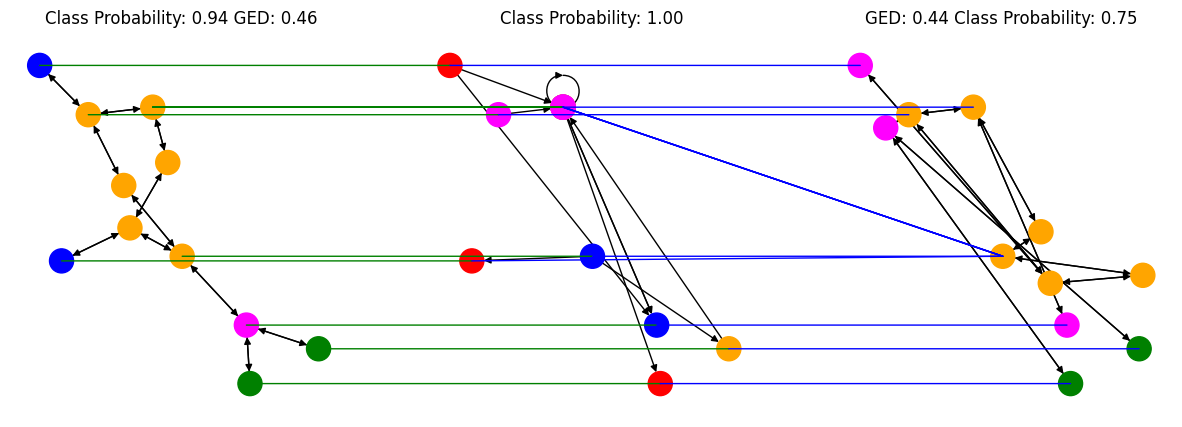

In [25]:
vis_con_graph(
    gen_gnnInt_0_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Multi-Layer Embedding Similarity

In [26]:
gen_gnnInt_1_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0241, 0.0338)
Baseline % GED to 1
(0.0879, 0.0904)
Baseline % GED to 0
(0.0674, 0.0789)
Epoch: 0 Losses:[2.0305545113303443, -0.358481788161126, 11550.95889559659, 2.6270376714793118]
Epoch: 1 Losses:[1.3593755852092395, -1.0245051817460493, 2053.383700284091, 2.7566477710550483]
Epoch: 2 Losses:[1.26217397776517, -1.173230994831432, 686.1883461692116, 2.8070117235183716]
Epoch: 3 Losses:[1.099996106191115, -1.3484958843751387, 259.6247836026278, 2.802124760367654]
Epoch: 4 Losses:[1.0214258269830183, -1.4688816395672886, 104.93776286732067, 2.8681294592944058]
Epoch: 5 Losses:[0.9586738456379283, -1.5492130409587512, 44.59918767755682, 2.840409614823081]
Epoch: 6 Losses:[0.9053145863793113, -1.6075870340520686, 19.988464442166414, 2.8423142487352546]
Epoch: 7 Losses:[0.8769942467862909, -1.652689196846702, 9.856178543784402, 2.82964732430198]
Epoch: 8 Losses:[0.9110327037897977, -1.6105402924797751, 5.536492911252108, 2.889966271140359]
Epoch: 9 Losse

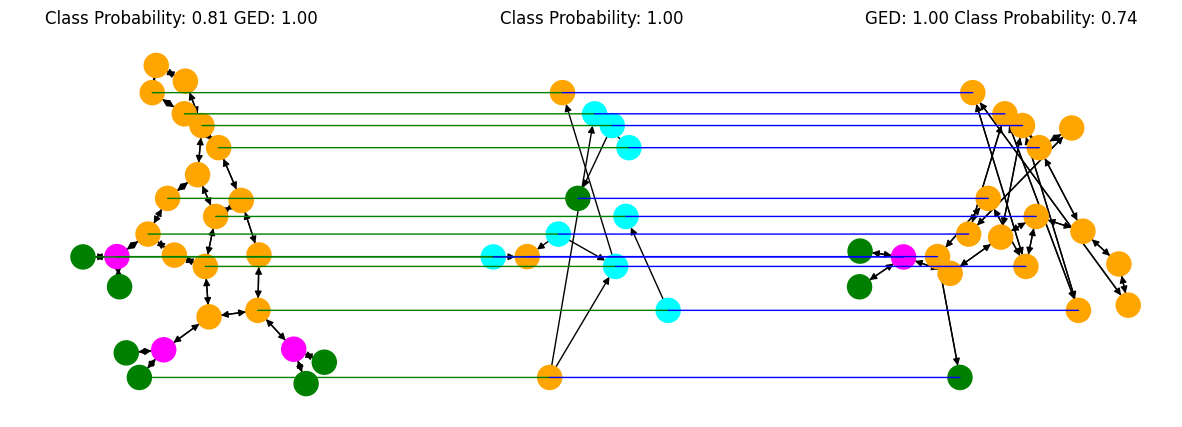

In [27]:
vis_con_graph(
    gen_gnnInt_1_ml, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [28]:
gen_gnnInt_0_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.8222, 0.8527)
Baseline % GED to 1
(0.0839, 0.0882)
Baseline % GED to 0
(0.0655, 0.0746)
Epoch: 0 Losses:[0.7550226449966431, -1.7970172817056829, 12304.745716441761, -2.642643083225597]
Epoch: 1 Losses:[0.7178588184443387, -1.805950023911216, 2024.8675315163352, -2.7176483869552612]
Epoch: 2 Losses:[0.717262403531508, -1.8289897441864014, 636.4301286177201, -2.781989422711459]
Epoch: 3 Losses:[0.6890694824132052, -1.830263235352256, 245.0344099564986, -2.785693493756381]
Epoch: 4 Losses:[0.7078952789306641, -1.8058486093174329, 104.92473602294922, -2.8120403831655327]
Epoch: 5 Losses:[0.6786088943481445, -1.8264108354395086, 47.40710241144354, -2.770400285720825]
Epoch: 6 Losses:[0.677530440417203, -1.8007872104644775, 22.748289108276367, -2.6942088820717554]
Epoch: 7 Losses:[0.6758585301312533, -1.8095590418035334, 11.451661543412643, -2.757964930751107]
Epoch: 8 Losses:[0.6618719805370678, -1.8302527774464001, 6.278430938720703, -2.718281875957142]
E

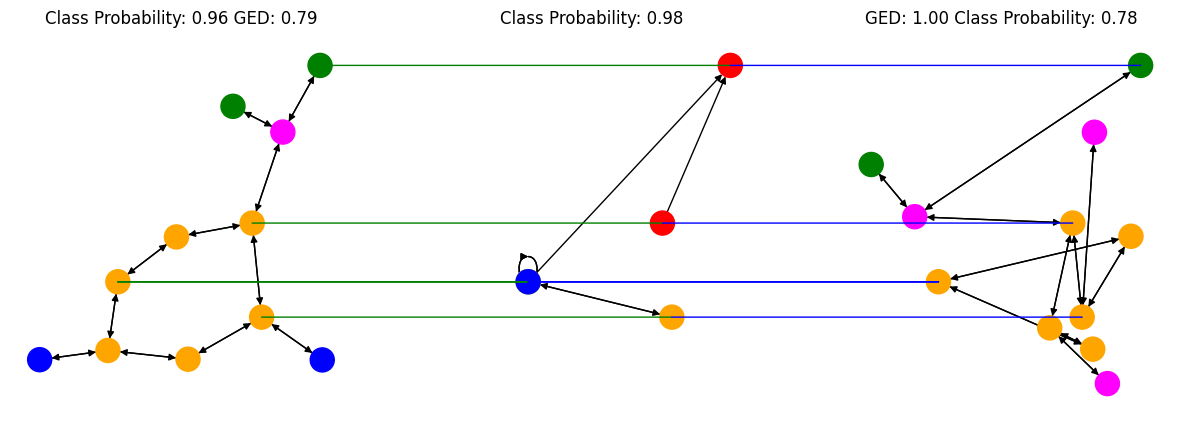

In [29]:
vis_con_graph(
    gen_gnnInt_0_ml,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [30]:
gen_gnnInt_1_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0002, 0.0004)
Baseline % GED to 1
(0.0781, 0.0829)
Baseline % GED to 0
(0.0612, 0.0704)
Epoch: 0 Losses:[2.345576828176325, -0.06410373848947612, 12535.546209161932, 2.5509657859802246]
Epoch: 1 Losses:[2.183889389038086, -0.05748059058731252, 2066.579012784091, 2.4219246723435144]
Epoch: 2 Losses:[1.9019184546037153, -0.139735032888976, 643.779316295277, 2.3893543265082617]
Epoch: 3 Losses:[1.494399374181574, -0.39576710896058515, 244.07221152565697, 2.2736304185607215]
Epoch: 4 Losses:[1.095025116747076, -0.9028024104508486, 104.91156352650036, 2.276460745117881]
Epoch: 5 Losses:[0.9470404765822671, -1.137632505460219, 46.0539699901234, 2.286789346824993]
Epoch: 6 Losses:[0.8994536183097146, -1.1970977024598555, 21.244116262956098, 2.2474924434315073]
Epoch: 7 Losses:[0.8787788911299272, -1.267639073458585, 10.564496863972057, 2.2627301649613814]
Epoch: 8 Losses:[0.8144864981824701, -1.3437977216460488, 5.903949347409335, 2.2111371701413933]
Epoch: 9

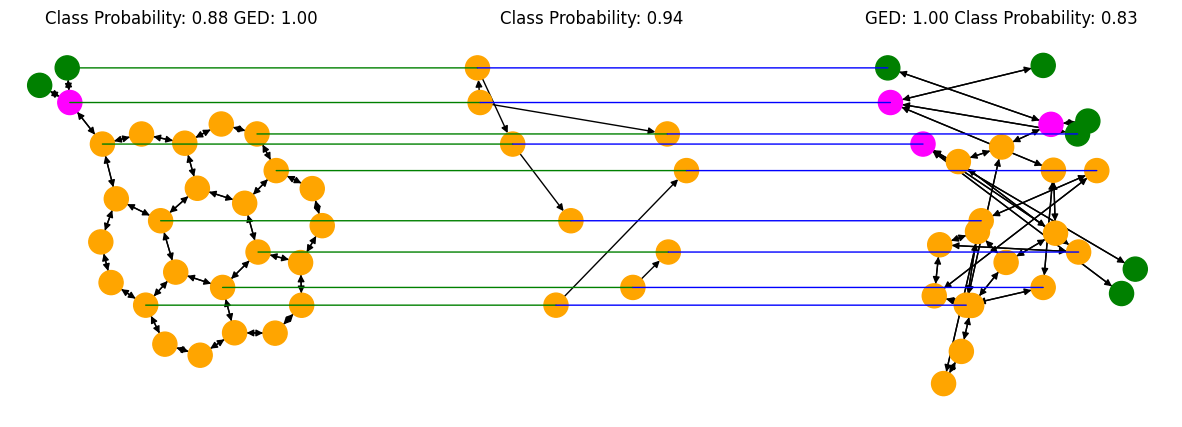

In [31]:
vis_con_graph(
    gen_gnnInt_1_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [32]:
gen_gnnInt_0_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9563, 0.9662)
Baseline % GED to 1
(0.0741, 0.077)
Baseline % GED to 0
(0.0624, 0.0717)
Epoch: 0 Losses:[0.5712251338091764, -1.8560224446383389, 11928.357044566761, -2.3616431788964705]
Epoch: 1 Losses:[0.5078520693562247, -1.8569540002129294, 1877.9445856267755, -2.345300782810558]
Epoch: 2 Losses:[0.47925820675763214, -1.8352609005841343, 582.0688726251775, -2.3277555975047024]
Epoch: 3 Losses:[0.467500854622234, -1.8280541788447986, 217.63316761363637, -2.3004183823412117]
Epoch: 4 Losses:[0.4815719561143355, -1.8019579323855313, 90.10934101451527, -2.3262381770394067]
Epoch: 5 Losses:[0.4957964339039542, -1.763015541163358, 39.855727282437414, -2.29897403717041]
Epoch: 6 Losses:[0.49214177510955115, -1.7901507399298928, 18.39830103787509, -2.4054474126208913]
Epoch: 7 Losses:[0.49217144738544116, -1.8031648939306086, 9.200466589494185, -2.4255785075100986]
Epoch: 8 Losses:[0.4961067573590712, -1.7769446698102085, 5.330169027501887, -2.3986942984841

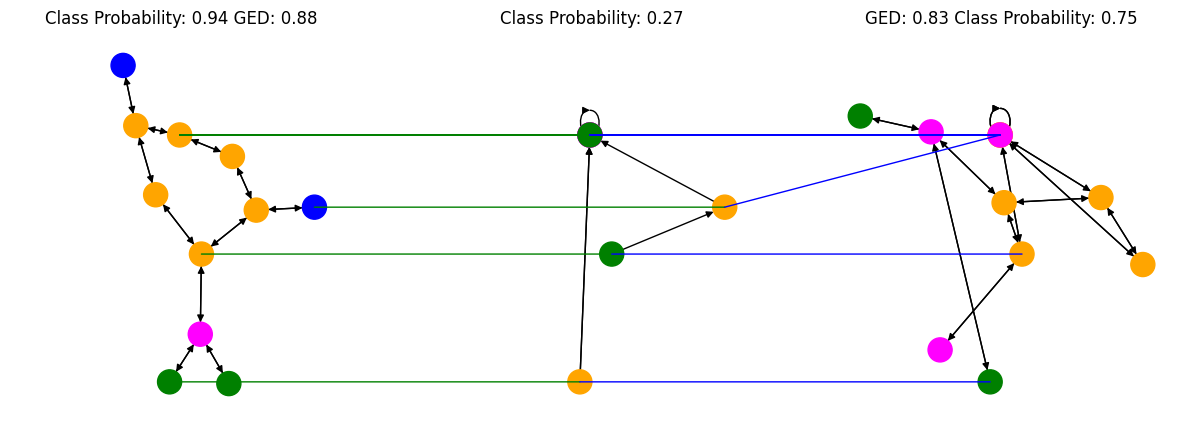

In [33]:
vis_con_graph(
    gen_gnnInt_0_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Opposing Class Embeddings

In [122]:
gen_gnnInt_1_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.11882362645678222 SD: 0.06282649683492748
(0.1149, 0.1227)
Baseline % GED to 1
Mean 0.08773344222988401 SD: 0.002130296233541942
(0.0858, 0.0897)
Baseline % GED to 0
Mean 0.07390174828469753 SD: 0.005322974490710552
(0.0683, 0.0795)
Epoch: 0 Losses:[1.6989596106789329, -0.5748556662689556, 11450.75830078125, 2.585106226530942]
Epoch: 1 Losses:[1.0972227508371526, -0.8756411454894326, 2065.076338334517, 2.8184219273653897]
Epoch: 2 Losses:[0.9686367511749268, -0.9742170843211088, 556.8994445800781, 2.9074011715975674]
Epoch: 3 Losses:[0.9004927494309165, -1.0230033235116438, 177.4038876620206, 2.905875715342435]
Epoch: 4 Losses:[0.8738522367043928, -1.0629312883723865, 57.956385525790125, 2.8794534748250786]
Epoch: 5 Losses:[0.8942226604981856, -1.0668315291404724, 20.301396630027078, 2.936555504798889]
Epoch: 6 Losses:[0.8413716933944009, -1.1049718856811523, 8.412200710990213, 2.9930536205118354]
Epoch: 7 Losses:[0.8045333786444231, -1.11742698062

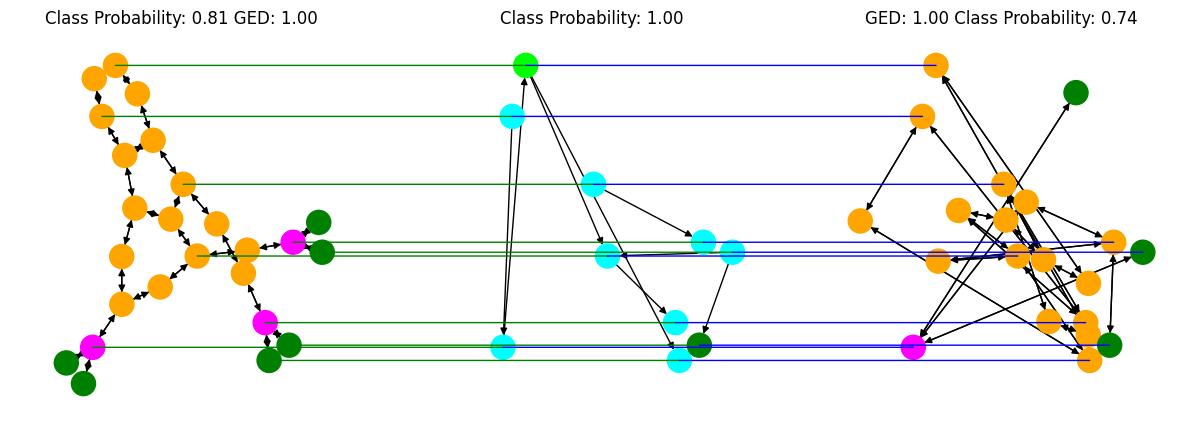

In [125]:
vis_con_graph(
    gen_gnnInt_1_oc, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [126]:
gen_gnnInt_0_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9556787910461426 SD: 0.03498180170411157
(0.9535, 0.9578)
Baseline % GED to 1
Mean 0.08766776642629079 SD: 0.002536666722167506
(0.0853, 0.09)
Baseline % GED to 0
Mean 0.07252739804486434 SD: 0.0053059507050717105
(0.067, 0.0781)
Epoch: 0 Losses:[0.7251557220112194, -1.1671049269762905, 12339.881303267046, -2.707479487765919]
Epoch: 1 Losses:[0.7539272308349609, -1.1975389935753562, 1970.5822088068182, -2.865137988870794]
Epoch: 2 Losses:[0.7501242431727323, -1.2092744762247258, 625.5792929909446, -2.9649417400360107]
Epoch: 3 Losses:[0.7578978375955061, -1.223123843019659, 239.1279199773615, -2.995019620115107]
Epoch: 4 Losses:[0.7792378826574846, -1.209597891027277, 102.24052498557351, -3.0435364679856733]
Epoch: 5 Losses:[0.76481863043525, -1.2217107144269077, 46.37772993607955, -3.008016727187417]
Epoch: 6 Losses:[0.7679502909833734, -1.2224481214176526, 22.155694181268867, -3.00200279192491]
Epoch: 7 Losses:[0.77406921711835, -1.23914164846593

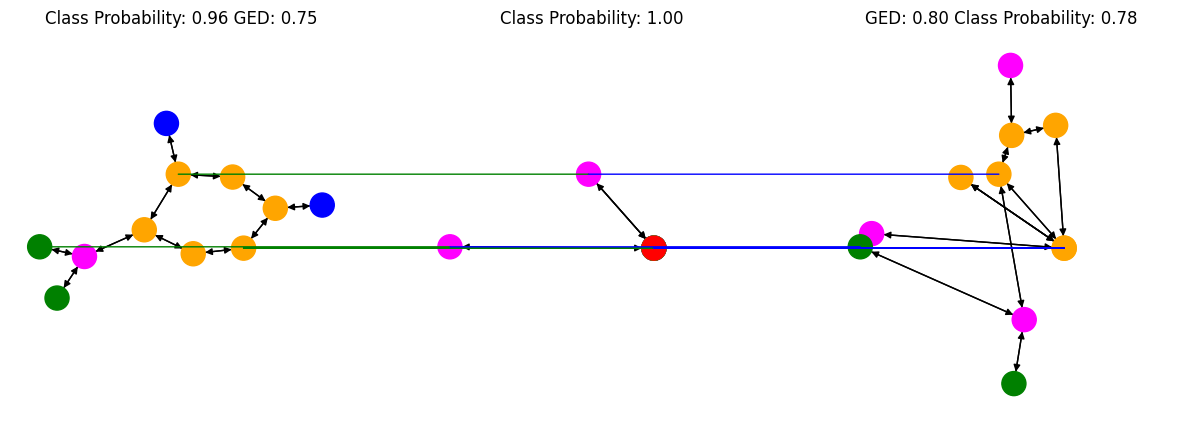

In [127]:
vis_con_graph(
    gen_gnnInt_0_oc,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [38]:
gen_gnnInt_1_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.002, 0.0038)
Baseline % GED to 1
(0.0768, 0.0826)
Baseline % GED to 0
(0.0606, 0.0684)
Epoch: 0 Losses:[2.334224982695146, -0.22619326683607968, 11653.734752308239, 2.4434113935990767]
Epoch: 1 Losses:[2.1439015106721357, -0.13877637684345245, 1865.3970281427557, 2.349125450307673]
Epoch: 2 Losses:[1.7625465609810569, -0.19006223841146988, 584.9173639470881, 2.18710458278656]
Epoch: 3 Losses:[1.1961215951225974, -0.4217902665788477, 253.64825439453125, 2.175817435437983]
Epoch: 4 Losses:[0.8885840340094133, -0.6243313848972321, 118.0340243252841, 2.168852052905343]
Epoch: 5 Losses:[0.8311813256957314, -0.6954124678264965, 53.563085382634945, 2.1729339361190796]
Epoch: 6 Losses:[0.702515347437425, -0.783508376641707, 24.90867129239169, 2.209884323857047]
Epoch: 7 Losses:[0.6514120318672874, -0.8147030472755432, 12.451648018576883, 2.1867421757091177]
Epoch: 8 Losses:[0.6765391284769232, -0.81799147345803, 6.69873705777255, 2.198109046979384]
Epoch: 9 Lo

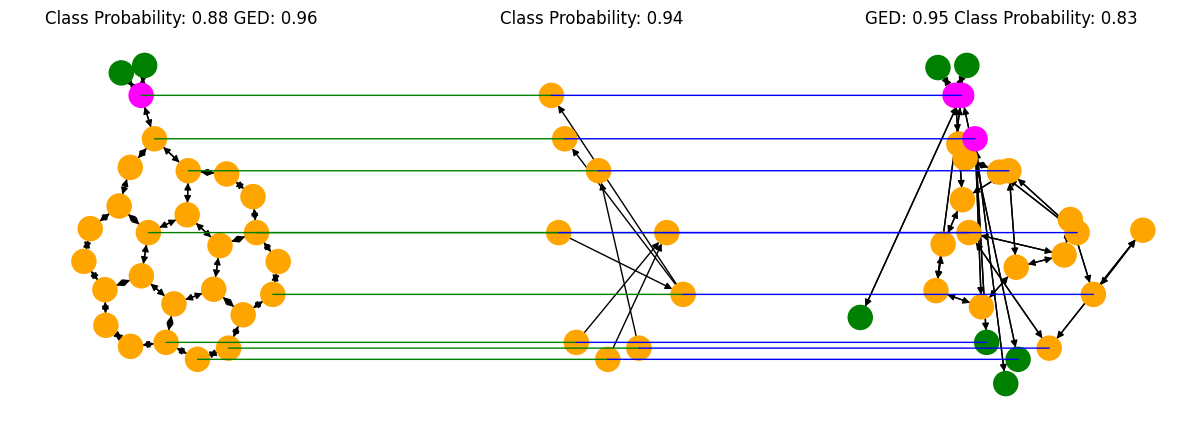

In [39]:
vis_con_graph(
    gen_gnnInt_1_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [40]:
gen_gnnInt_0_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9668, 0.9749)
Baseline % GED to 1
(0.0797, 0.0825)
Baseline % GED to 0
(0.0684, 0.0711)
Epoch: 0 Losses:[0.6006321040066805, -1.0955596295270054, 11737.380260120739, -2.617997646331787]
Epoch: 1 Losses:[0.6146282878789034, -1.1204218430952593, 1878.1350929953835, -2.8646469007838857]
Epoch: 2 Losses:[0.6293442628600381, -1.140025182203813, 568.7229697487571, -2.8803755911913784]
Epoch: 3 Losses:[0.6376962932673368, -1.148694320158525, 206.17496837269175, -2.9338804483413696]
Epoch: 4 Losses:[0.6366550868207758, -1.1483057737350464, 84.17499160766602, -2.960770520296964]
Epoch: 5 Losses:[0.6388005126606334, -1.1509359858252786, 36.55091736533425, -3.0182810479944404]
Epoch: 6 Losses:[0.6485573866150596, -1.162030664357272, 16.577982902526855, -3.0080505392768164]
Epoch: 7 Losses:[0.6462808793241327, -1.1585233428261497, 8.324814969843084, -2.970716790719466]
Epoch: 8 Losses:[0.6467331972989169, -1.1593732292001897, 4.85808177427812, -3.0281641374934805]

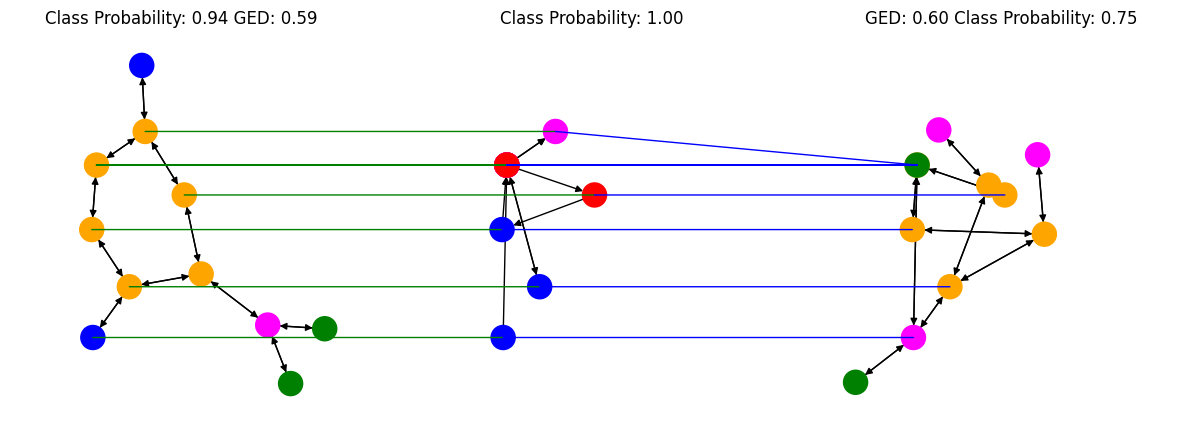

In [41]:
vis_con_graph(
    gen_gnnInt_0_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Only GED

In [42]:
gen_gnnInt_1_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-4, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.0285, 0.0419)
Baseline % GED to 1
(0.0844, 0.088)
Baseline % GED to 0
(0.0668, 0.075)
Epoch: 0 Losses:[2.3079168146306817, -0.3648686110973358, 14035.912420099432, 2.4770980694077234]
Epoch: 1 Losses:[2.277829256924716, -0.3183248720385812, 3122.3942538174715, 2.234082720496438]
Epoch: 2 Losses:[2.094474131410772, -0.2790713906288147, 1458.2845237038352, 2.0995635254816576]
Epoch: 3 Losses:[1.9760011109438809, -0.2604438066482544, 836.5978948419744, 1.8574940291318027]
Epoch: 4 Losses:[1.9081680341200395, -0.23124513300982388, 562.5385991876775, 1.7525672641667454]
Epoch: 5 Losses:[1.7632299011403865, -0.23538712208921259, 411.650127064098, 1.6299626610495828]
Epoch: 6 Losses:[1.646853056820956, -0.2374305007132617, 341.6121299050071, 1.5696170167489485]
Epoch: 7 Losses:[1.524678717960011, -0.2786736488342285, 293.2379427823153, 1.459914418784055]
Epoch: 8 Losses:[1.5092076388272373, -0.2576636319810694, 260.9140527898615, 1.3860759951851584]
Epoch: 9 

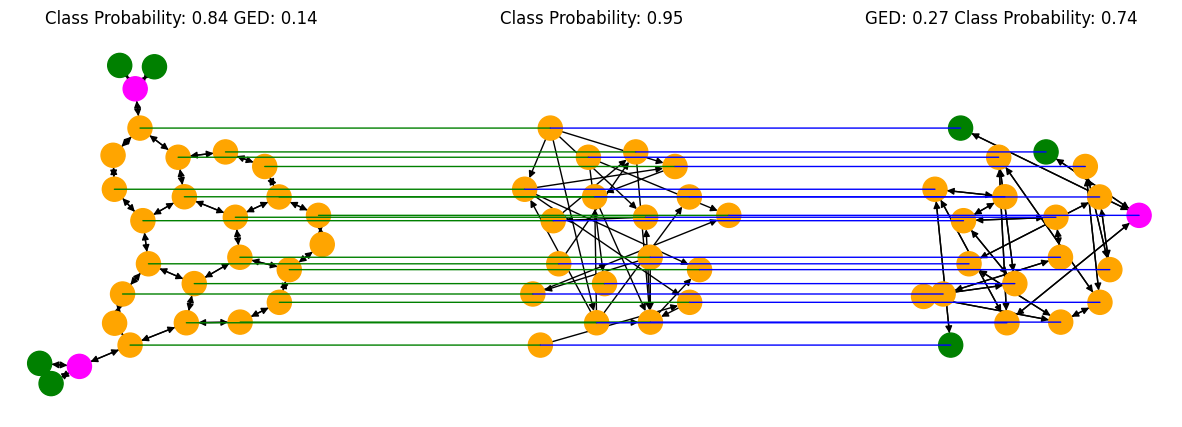

In [72]:
vis_con_graph(
    gen_gnnInt_1_GED, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[3].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [44]:
gen_gnnInt_0_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.8481, 0.8747)
Baseline % GED to 1
(0.0826, 0.0864)
Baseline % GED to 0
(0.0666, 0.0742)
Epoch: 0 Losses:[0.9076341444795782, -1.036517170342532, 15516.223854758522, -2.7897195436737756]
Epoch: 1 Losses:[0.8504552624442361, -1.0905607288533992, 4486.8017578125, -2.839488376270641]
Epoch: 2 Losses:[0.857383050701835, -1.0883903503417969, 2282.1239790482955, -2.8851503242145884]
Epoch: 3 Losses:[0.9281701824881814, -1.0527143532579595, 1318.9273071289062, -2.895425937392495]
Epoch: 4 Losses:[0.8517699458382346, -1.0912576913833618, 758.1468283913352, -2.9220064011487095]
Epoch: 5 Losses:[0.8276974233714017, -1.1099161993373523, 439.12240323153407, -2.906770337711681]
Epoch: 6 Losses:[0.8224256959828463, -1.1087510910901157, 253.71438043767756, -2.9240835146470503]
Epoch: 7 Losses:[0.8498985279690136, -1.0877902182665737, 151.09054079922763, -2.9186672514135186]
Epoch: 8 Losses:[0.8463205695152283, -1.0913714929060503, 86.09033549915661, -2.907522136514837

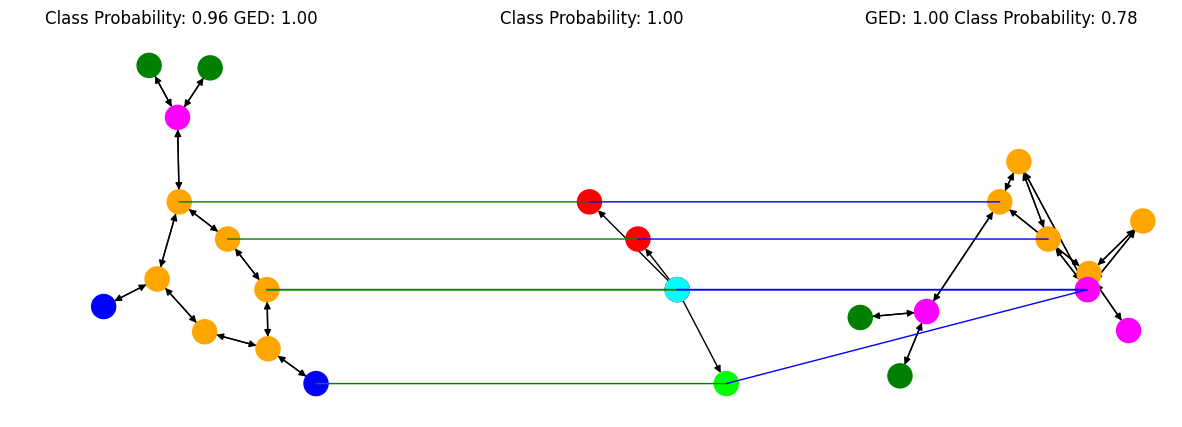

In [45]:
vis_con_graph(
    gen_gnnInt_0_GED,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [46]:
gen_gnnInt_1_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.0104, 0.0146)
Baseline % GED to 1
(0.0753, 0.0796)
Baseline % GED to 0
(0.0615, 0.0718)
Epoch: 0 Losses:[2.296033815904097, -0.1977419297803532, 17897.130237926136, 2.036334530873732]
Epoch: 1 Losses:[2.1800385171716865, -0.12883145158941095, 12599.929509943182, 1.7020058794455095]
Epoch: 2 Losses:[2.107344063845548, -0.10955741256475449, 12384.341530539772, 1.4857390577142888]
Epoch: 3 Losses:[2.042389013550498, -0.10298825258558447, 12298.990500710228, 1.3946053223176436]
Epoch: 4 Losses:[1.9174264127557927, -0.12267298928715965, 12395.8984375, 1.3019787344065579]
Epoch: 5 Losses:[1.9009781750765713, -0.12873524630611594, 12365.3740234375, 1.2726273455403068]
Epoch: 6 Losses:[1.7636919671838933, -0.1830987645821138, 12475.480202414772, 1.1164692802862688]
Epoch: 7 Losses:[1.6678497357801958, -0.22228909487074072, 12593.430841619318, 1.0980268012393604]
Epoch: 8 Losses:[1.5266570069573142, -0.2990950725295327, 12513.351917613636, 1.0877220766110853]
E

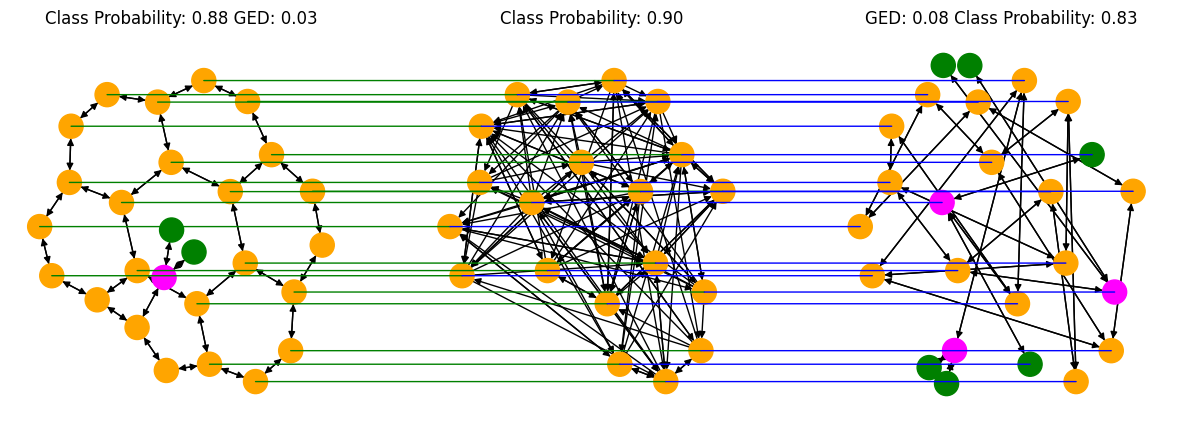

In [47]:
vis_con_graph(
    gen_gnnInt_1_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [48]:
gen_gnnInt_0_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.9992, 0.9996)
Baseline % GED to 1
(0.0824, 0.0843)
Baseline % GED to 0
(0.0667, 0.0766)
Epoch: 0 Losses:[0.6413810849189758, -1.1537214409221301, 13405.1572265625, -2.811814546585083]
Epoch: 1 Losses:[0.6596758582375266, -1.1720817197452893, 3745.5430131392045, -2.9838024269450796]
Epoch: 2 Losses:[0.6722609780051492, -1.1830340732227673, 1959.186356977983, -3.092253576625477]
Epoch: 3 Losses:[0.678411760113456, -1.1888628656213933, 1105.588290127841, -3.0807229497215967]
Epoch: 4 Losses:[0.684134607965296, -1.1937920180234043, 650.9532775878906, -3.1803826202045786]
Epoch: 5 Losses:[0.6878473271023143, -1.197113730690696, 344.7614440917969, -3.1455622261220757]
Epoch: 6 Losses:[0.692857866937464, -1.200201858173717, 205.15519159490412, -3.1243644627657803]
Epoch: 7 Losses:[0.6966899091547186, -1.2031172080473467, 110.78136374733664, -3.1445297327908603]
Epoch: 8 Losses:[0.7020516720685092, -1.2060485319657759, 54.50078235973012, -3.1483576081015845]
E

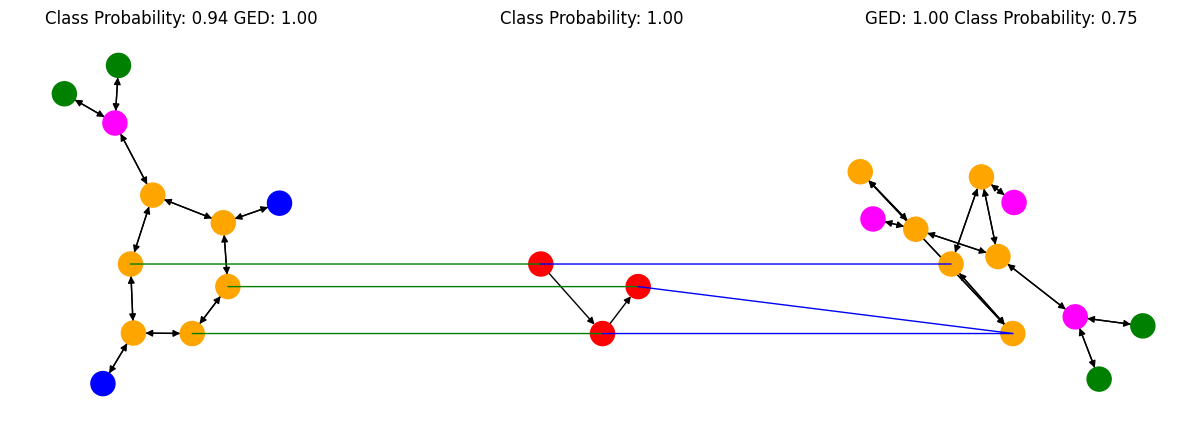

In [49]:
vis_con_graph(
    gen_gnnInt_0_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Full Loss

In [100]:
gen_gnnInt_1_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.20946938853524624 SD: 0.07533244975094704
(0.2048, 0.2141)
Baseline % GED to 1
Mean 0.08441860441650663 SD: 0.0017318958821288125
(0.0828, 0.086)
Baseline % GED to 0
Mean 0.0706717229137818 SD: 0.004646337155634459
(0.0658, 0.0755)
Epoch: 0 Losses:[1.4365993629802356, -0.7101838101040233, 22393.580433238636, 2.528845955025066]
Epoch: 1 Losses:[1.031868744980205, -0.9165729826146906, 16188.62686434659, 2.3331022912805732]
Epoch: 2 Losses:[0.8095137043432756, -1.0465011488307605, 14839.492453835228, 2.230171729217876]
Epoch: 3 Losses:[0.7926022410392761, -1.060088038444519, 14303.608753551136, 2.177266148003665]
Epoch: 4 Losses:[0.7737596901980314, -1.0853900042447178, 14168.21768465909, 2.054223743352023]
Epoch: 5 Losses:[0.7705588611689481, -1.0833770903674038, 14553.931906960228, 1.9530519057403912]
Epoch: 6 Losses:[0.7309751510620117, -1.0896911729465832, 14496.885298295454, 1.8821743591265245]
Epoch: 7 Losses:[0.7654493234374307, -1.074959234757

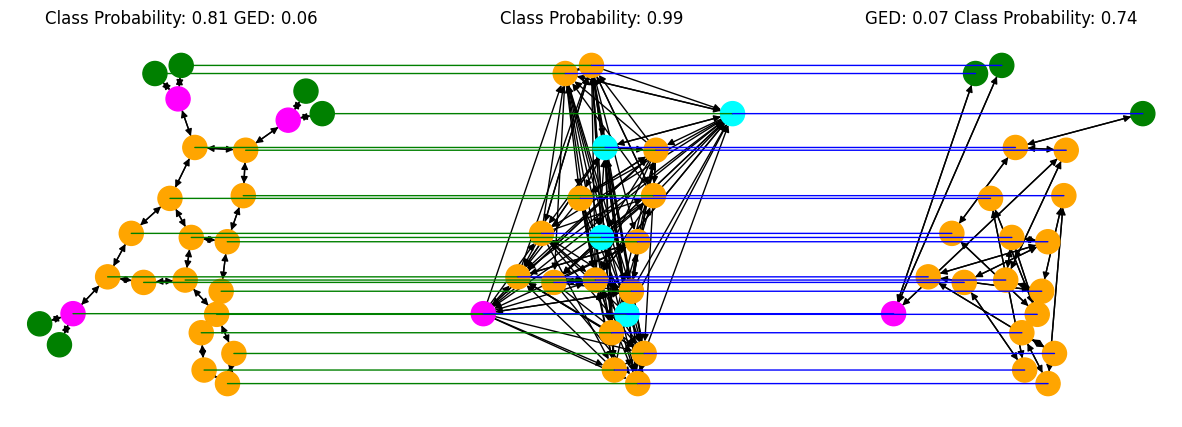

In [104]:
vis_con_graph(
    gen_gnnInt_1_full, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [109]:
gen_gnnInt_0_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1e6]), 
)

Baseline Prediction Accuracy: 
Mean 0.9636014497280121 SD: 0.03333574187208654
(0.9615, 0.9657)
Baseline % GED to 1
Mean 0.08006198065621513 SD: 0.0022739489691209784
(0.078, 0.0822)
Baseline % GED to 0
Mean 0.06539181744058926 SD: 0.004766475973467036
(0.0604, 0.0704)
Epoch: 0 Losses:[0.7123217365958474, -1.1233824491500854, 27509.361683238636, -2.7159412828358738]
Epoch: 1 Losses:[0.7640958645127036, -1.1321340907703747, 17081.890358664772, -2.7820373448458584]
Epoch: 2 Losses:[0.7516920187256553, -1.1764897216450085, 12738.773881392046, -2.8723835186524824]
Epoch: 3 Losses:[0.7573318427259271, -1.1635082309896296, 9845.554332386364, -2.8913758126172153]
Epoch: 4 Losses:[0.7673704786734148, -1.179617318240079, 7828.9716796875, -2.8898119926452637]
Epoch: 5 Losses:[0.7990732084621083, -1.167267842726274, 6394.192160866477, -2.9992835521698]
Epoch: 6 Losses:[0.7756786888295953, -1.2048488638617776, 5060.733620383523, -3.023659651929682]
Epoch: 7 Losses:[0.7642364231022921, -1.199706337

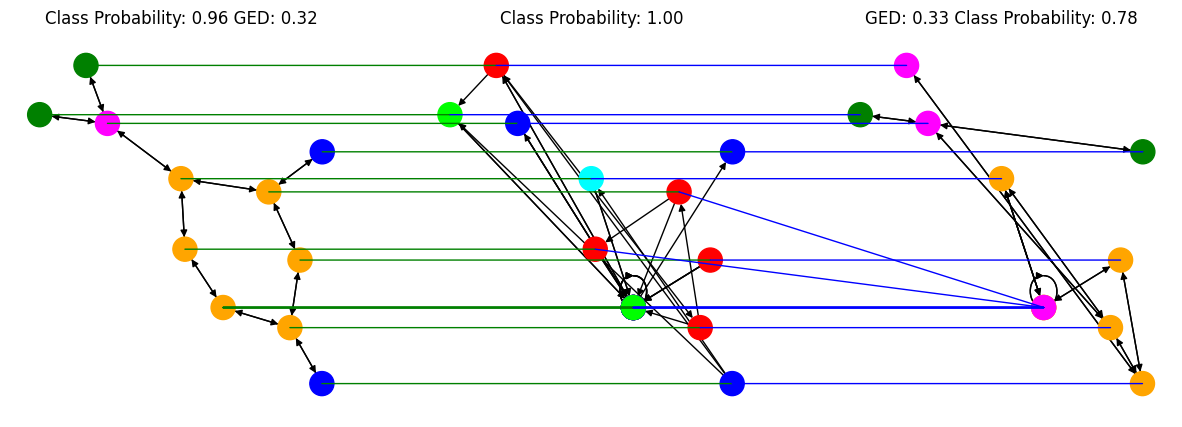

In [114]:
vis_con_graph(
    gen_gnnInt_0_full,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [54]:
gen_gnnInt_1_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
    epochs=25
)

Baseline Prediction Accuracy: 
(0.0032, 0.006)
Baseline % GED to 1
(0.0716, 0.0753)
Baseline % GED to 0
(0.056, 0.0627)
Epoch: 0 Losses:[2.373762152411721, -0.2563805268569426, 23285.558238636364, 2.1522593877532263]
Epoch: 1 Losses:[2.28626689043912, -0.1919563263654709, 15607.635475852272, 1.8817517107183284]
Epoch: 2 Losses:[2.184603821147572, -0.14026622000065717, 14306.774946732954, 1.6612577709284695]
Epoch: 3 Losses:[2.0903738628734243, -0.11074186387387189, 13945.0673828125, 1.380022178996693]
Epoch: 4 Losses:[1.9585334821180864, -0.12470263581384312, 13956.51171875, 1.3217568885196338]
Epoch: 5 Losses:[1.7597225037488071, -0.1951437843116847, 13900.541814630682, 1.2351332361047918]
Epoch: 6 Losses:[1.5310181270946155, -0.29212311723015527, 13791.521129261364, 1.1187318129972978]
Epoch: 7 Losses:[1.2725219509818337, -0.42092950506643817, 13856.209783380682, 1.0547544089230625]
Epoch: 8 Losses:[1.0062086257067593, -0.5886042768304999, 13646.218572443182, 1.0038729492913594]
Epoc

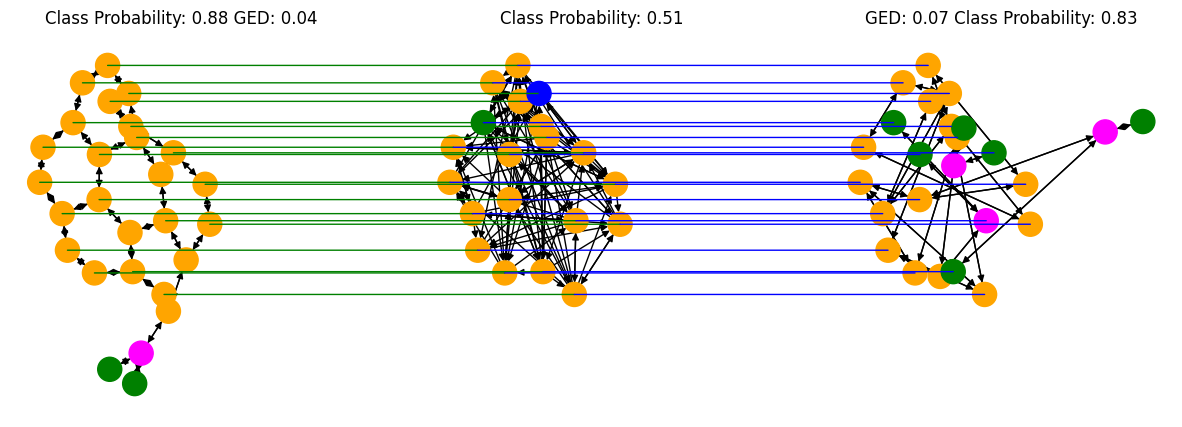

In [55]:
vis_con_graph(
    gen_gnnInt_1_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [56]:
gen_gnnInt_0_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.9884, 0.9921)
Baseline % GED to 1
(0.0794, 0.0822)
Baseline % GED to 0
(0.0664, 0.0698)
Epoch: 0 Losses:[0.6214178583838723, -1.1355917995626277, 14450.610617897728, -2.711835026741028]
Epoch: 1 Losses:[0.6382171457464044, -1.1552852934057063, 4213.494273792614, -2.942922440442172]
Epoch: 2 Losses:[0.6432714028791948, -1.1603643460707231, 2089.0336359197445, -3.093216982754794]
Epoch: 3 Losses:[0.6505627903071317, -1.167248097333041, 1163.3369085138495, -3.0314073779366235]
Epoch: 4 Losses:[0.6551520120013844, -1.1705224188891323, 690.1352095170455, -3.121760216626254]
Epoch: 5 Losses:[0.6606082320213318, -1.1747023300691084, 392.1585415926847, -3.1611676649613814]
Epoch: 6 Losses:[0.6663850491697138, -1.1788252592086792, 240.36449640447444, -3.102362556891008]
Epoch: 7 Losses:[0.6655110066587274, -1.1784581704573198, 154.88960404829547, -3.135951215570623]
Epoch: 8 Losses:[0.6710527755997397, -1.1821772185238926, 92.06660253351384, -3.145424734462391]

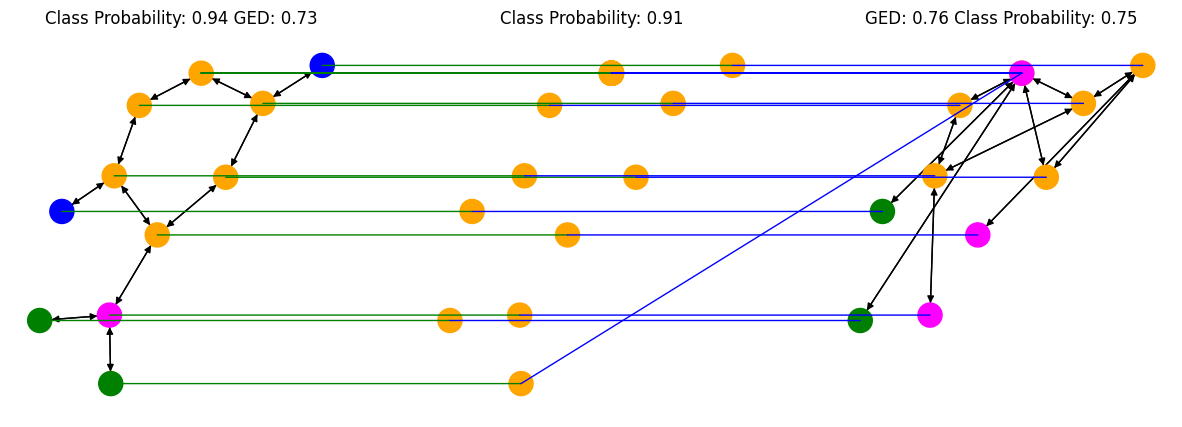

In [66]:
vis_con_graph(
    gen_gnnInt_0_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Parameter Distribution

In [115]:
data_0 = train_data_list_0 + test_data_list_0
data_1 = train_data_list_1 + test_data_list_1

batch_0 = pyg.data.Batch.from_data_list(data_0)
batch_1 = pyg.data.Batch.from_data_list(data_1)

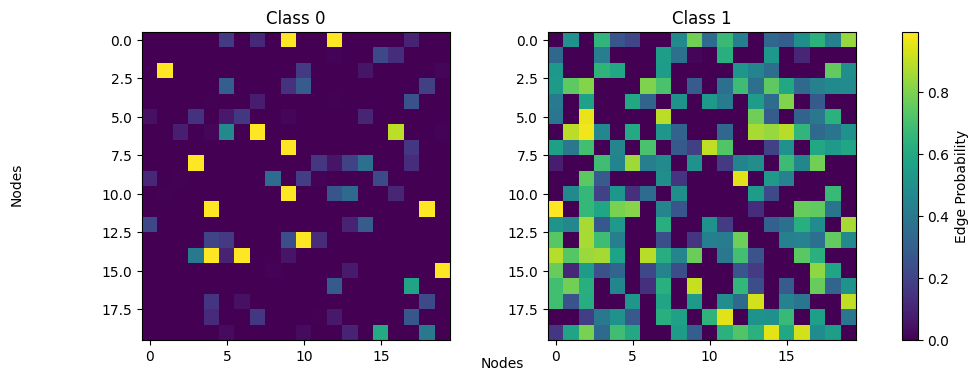

In [116]:
edge_probs_0 = gen_gnnInt_0_full.AdjacencyMatrix.probs
edge_probs_0 = edge_probs_0.detach().cpu().numpy()

edge_probs_1 = gen_gnnInt_1_full.AdjacencyMatrix.probs
edge_probs_1 = edge_probs_1.detach().cpu().numpy()

# edge_probs_untrained = generator_untrained.AdjacencyMatrix.probs
# edge_probs_untrained = edge_probs_untrained.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(edge_probs_0, cmap='viridis', interpolation='nearest')
im1 = axes[1].imshow(edge_probs_1, cmap='viridis', interpolation='nearest')
#im2 = axes[2].imshow(edge_probs_untrained, cmap='viridis', interpolation='nearest')

# Add a common color bar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label('Edge Probability')

# Set titles
axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
# axes[2].set_title('Untrained')

# Set common x and y labels
fig.text(0.45, 0.04, 'Nodes', ha='center')
fig.text(0.04, 0.5, 'Nodes', va='center', rotation='vertical')

plt.show()

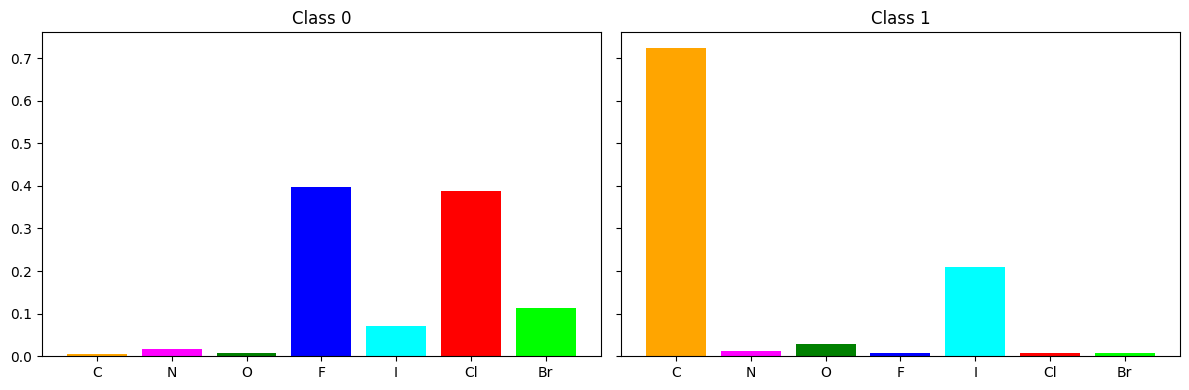

In [117]:
cell_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_0 = cell_type_probs_0.detach().cpu().numpy()

cell_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_1 = cell_type_probs_1.detach().cpu().numpy()

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[1].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

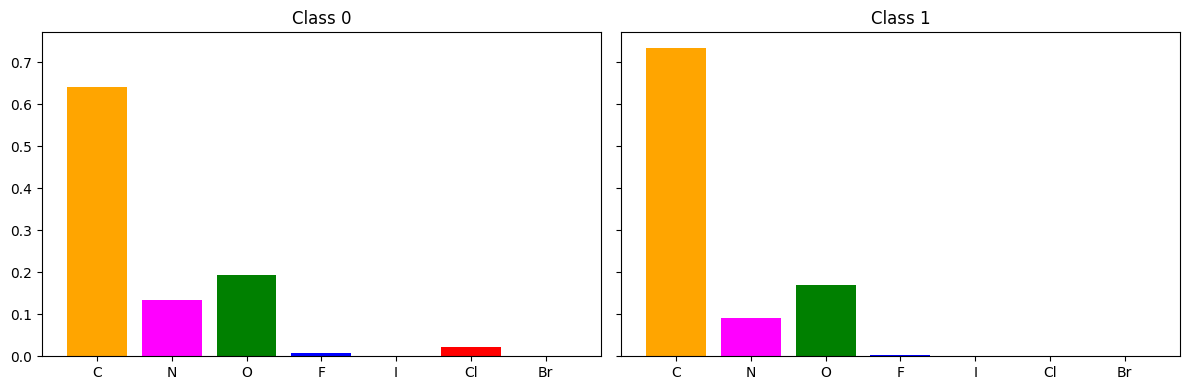

In [118]:
emp_dist_node_0 = batch_0.x.argmax(dim=-1).numpy()
emp_dist_node_1 = batch_1.x.argmax(dim=-1).numpy()

# Empirical node type probabilities
unique_classes_0, counts_0 = np.unique(emp_dist_node_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_node_0))
percentages_0 = np.insert(percentages_0, 4, 0.0) # missing I

unique_classes_1, counts_1 = np.unique(emp_dist_node_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_node_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']

axes[0].bar(plot_indices, percentages_0, color=color_palette)
axes[1].bar(plot_indices, percentages_1, color=color_palette)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')

plt.tight_layout()
plt.show()

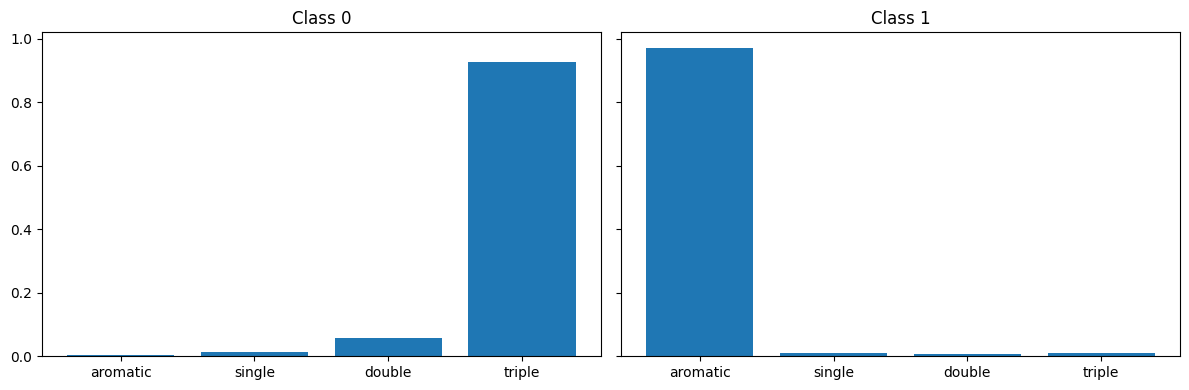

In [119]:
edge_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_0 = edge_type_probs_0.detach().cpu().numpy()

edge_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_1 = edge_type_probs_1.detach().cpu().numpy()

# edge_type_probs_untrained = torch.softmax(
#     generator_untrained.DisEdgeFeats[0].probs, dim=0)
# edge_type_probs_untrained = edge_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, edge_type_probs_0)
axes[1].bar(plot_indices, edge_type_probs_1)
#axes[2].bar(plot_indices, edge_type_probs_untrained)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

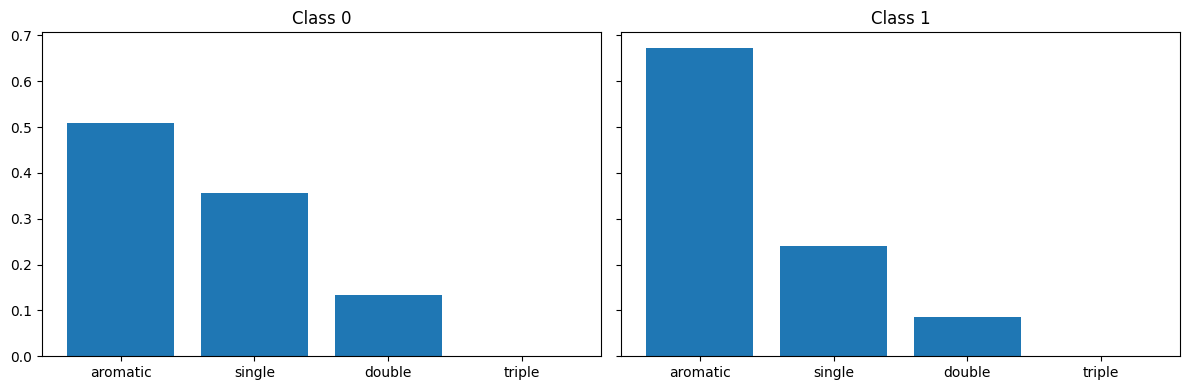

In [120]:
# Empirical edge type probabilities
emp_dist_edge_0 = batch_0.edge_attr.argmax(dim=-1).numpy()
emp_dist_edge_1 = batch_1.edge_attr.argmax(dim=-1).numpy()

unique_classes_0, counts_0 = np.unique(emp_dist_edge_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_edge_0))
percentages_0 = np.insert(percentages_0, 3, 0.0) # no triples. 

unique_classes_1, counts_1 = np.unique(emp_dist_edge_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_edge_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(edge_types, percentages_0)
axes[1].bar(edge_types, percentages_1)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')

plt.tight_layout()
plt.show()

### Clean-UP

In [121]:
import gc

# Get all objects in the current context
for obj in gc.get_objects():
    if torch.is_tensor(obj) and obj.is_cuda:
        del obj

# Clear the cache
torch.cuda.empty_cache()

# Optionally synchronize (wait for GPU computations to finish)
torch.cuda.synchronize()